# Nepal Solar Resource Analysis
## Phase 1: GHI Trend and Variability Analysis for 33 Districts (2005–2023)

**Author:** Smoky_Quartz 
**Date:** June 2026  
**Data source:** PVGIS ERA5, European Commission Joint Research Centre  
**API:** https://re.jrc.ec.europa.eu/api/v5_3/MRcalc  

This notebook analyses annual solar irradiance (GHI) trends and inter-annual 
variability for 33 districts across Nepal's Terai, Hill, and Mountain zones 
using PVGIS ERA5 satellite-reanalysis data from 2005 to 2023.

Full methodology and findings are documented in the Key Findings section below 
and in README.md.

In [1]:
import requests
import pandas as pd
import time

# --- LOCATIONS ---
# 33 districts selected to represent Nepal's principal solar resource zones:
# Terai lowlands (East to Far-West), Inner Terai, Hill belt (Central to Far-West),
# and Mountain zones including high-altitude rain shadow districts.
# Geographic coverage spans the full east-west and altitudinal gradient of Nepal.

locations = {
    # Eastern Terai
    "Jhapa":         {"lat": 26.60, "lon": 87.92, "zone": "Eastern Terai"},
    "Sunsari":       {"lat": 26.80, "lon": 87.18, "zone": "Eastern Terai"},
    "Siraha":        {"lat": 26.65, "lon": 86.19, "zone": "Eastern Terai"},

    # Madhesh Terai
    "Dhanusha":      {"lat": 26.87, "lon": 85.93, "zone": "Madhesh Terai"},
    "Mahottari":     {"lat": 26.91, "lon": 85.73, "zone": "Madhesh Terai"},
    "Sarlahi":       {"lat": 27.10, "lon": 85.55, "zone": "Madhesh Terai"},
    "Rautahat":      {"lat": 27.00, "lon": 85.30, "zone": "Madhesh Terai"},
    "Bara":          {"lat": 27.00, "lon": 85.00, "zone": "Madhesh Terai"},
    "Parsa":         {"lat": 27.13, "lon": 84.98, "zone": "Madhesh Terai"},

    # Western Terai
    "Nawalparasi":   {"lat": 27.57, "lon": 83.70, "zone": "Western Terai"},
    "Rupandehi":     {"lat": 27.57, "lon": 83.45, "zone": "Western Terai"},
    "Kapilvastu":    {"lat": 27.57, "lon": 83.05, "zone": "Western Terai"},

    # Inner Terai
    "Nawalpur":      {"lat": 27.69, "lon": 84.13, "zone": "Inner Terai"},
    "Dang":          {"lat": 28.10, "lon": 82.30, "zone": "Inner Terai"},

    # Mid-West Terai
    "Banke":         {"lat": 28.05, "lon": 81.62, "zone": "Mid-West Terai"},
    "Bardiya":       {"lat": 28.35, "lon": 81.26, "zone": "Mid-West Terai"},

    # Far-West Terai
    "Kailali":       {"lat": 28.77, "lon": 80.87, "zone": "Far-West Terai"},
    "Kanchanpur":    {"lat": 29.14, "lon": 80.27, "zone": "Far-West Terai"},

    # Central Hills (Bagmati zone)
    "Sindhupalchok": {"lat": 27.95, "lon": 85.68, "zone": "Central Hills"},
    "Gorkha":        {"lat": 28.00, "lon": 84.63, "zone": "Central Hills"},

    # Western Hills
    "Tanahun":       {"lat": 27.92, "lon": 84.25, "zone": "Western Hills"},
    "Palpa":         {"lat": 27.87, "lon": 83.54, "zone": "Western Hills"},
    "Gulmi":         {"lat": 28.08, "lon": 83.26, "zone": "Western Hills"},
    "Arghakhanchi":  {"lat": 27.97, "lon": 83.17, "zone": "Western Hills"},
    "Baglung":       {"lat": 28.27, "lon": 83.59, "zone": "Western Hills"},
    "Parbat":        {"lat": 28.38, "lon": 83.66, "zone": "Western Hills"},

    # Mid-West Hills
    "Rolpa":         {"lat": 28.23, "lon": 82.65, "zone": "Mid-West Hills"},

    # Far-West Hills
    "Dadeldhura":    {"lat": 29.30, "lon": 80.58, "zone": "Far-West Hills"},

    # Eastern Hills
    "Ramechhap":     {"lat": 27.33, "lon": 86.08, "zone": "Eastern Hills"},

    # Eastern Mountain
    "Sankhuwasabha": {"lat": 27.35, "lon": 87.27, "zone": "Eastern Mountain"},

    # High Mountain (rain shadow districts)
    "Mustang":       {"lat": 28.98, "lon": 83.85, "zone": "High Mountain"},
    "Dolpa":         {"lat": 29.05, "lon": 82.80, "zone": "High Mountain"},
    "Humla":         {"lat": 29.97, "lon": 82.15, "zone": "High Mountain"},
}


# --- FETCH FUNCTION (with timeout and retry) ---
def fetch_pvgis_monthly(lat, lon, location_name, zone, retries=3):
    url = "https://re.jrc.ec.europa.eu/api/v5_3/MRcalc"
    params = {
        "lat": lat,
        "lon": lon,
        "raddatabase": "PVGIS-ERA5",
        "outputformat": "json",
        "startyear": 2005,
        "endyear": 2023,
        "horirrad": 1,
        "mr_dni": 1,
    }
    for attempt in range(retries):
        try:
            response = requests.get(url, params=params, timeout=30)
            if response.status_code == 200:
                data = response.json()
                df = pd.DataFrame(data['outputs']['monthly'])
                df['location'] = location_name
                df['zone'] = zone
                return df
            else:
                print(f"  [{location_name}] HTTP {response.status_code} — attempt {attempt+1}/{retries}")
        except requests.exceptions.Timeout:
            print(f"  [{location_name}] Timeout — attempt {attempt+1}/{retries}")
        except requests.exceptions.RequestException as e:
            print(f"  [{location_name}] Error: {e} — attempt {attempt+1}/{retries}")
        time.sleep(2)
    print(f"  [{location_name}] Failed after {retries} attempts.")
    return None


# --- FETCH ALL LOCATIONS ---
all_data = []

for name, info in locations.items():
    print(f"Fetching {name}...")
    df = fetch_pvgis_monthly(info['lat'], info['lon'], name, info['zone'])
    if df is not None:
        all_data.append(df)

# --- COMBINE ---
df_all = pd.concat(all_data, ignore_index=True)

# --- AVERAGE MONTHLY VALUES (across all years) ---
df_monthly = df_all.groupby(['location', 'zone', 'month']).agg(
    GHI_monthly=('H(h)_m', 'mean'),
    DNI_monthly=('Hb(n)_m', 'mean')
).reset_index()

# --- ANNUAL GHI TOTAL PER LOCATION ---
df_annual = df_monthly.groupby(['location', 'zone']).agg(
    GHI_annual=('GHI_monthly', 'sum')
).reset_index().sort_values('GHI_annual', ascending=False)

print("\nDone. Annual GHI by district:")
print(df_annual.to_string(index=False))
print(f"\nTotal districts: {len(df_annual)}")

Fetching Jhapa...
Fetching Sunsari...
Fetching Siraha...
Fetching Dhanusha...
Fetching Mahottari...
Fetching Sarlahi...
Fetching Rautahat...
Fetching Bara...
Fetching Parsa...
Fetching Nawalparasi...
Fetching Rupandehi...
Fetching Kapilvastu...
Fetching Nawalpur...
Fetching Dang...
Fetching Banke...
Fetching Bardiya...
Fetching Kailali...
Fetching Kanchanpur...
Fetching Sindhupalchok...
Fetching Gorkha...
Fetching Tanahun...
Fetching Palpa...
Fetching Gulmi...
Fetching Arghakhanchi...
Fetching Baglung...
Fetching Parbat...
Fetching Rolpa...
Fetching Dadeldhura...
Fetching Ramechhap...
Fetching Sankhuwasabha...
Fetching Mustang...
Fetching Dolpa...
Fetching Humla...

Done. Annual GHI by district:
     location             zone  GHI_annual
      Mustang    High Mountain 1999.851053
        Dolpa    High Mountain 1818.498947
        Banke   Mid-West Terai 1813.398421
      Bardiya   Mid-West Terai 1798.395263
         Bara    Madhesh Terai 1797.285789
     Rautahat    Madhesh Terai 1788.2

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from scipy import stats as sp_stats

# --- ANNUAL GHI TREND OVER TIME (2005–2023) ---
df_yearly_trend = df_all.groupby(['location', 'zone', 'year']).agg(
    GHI_annual=('H(h)_m', 'sum')
).reset_index()

# --- ZONE COLORS ---
zone_colors = {
    "Eastern Terai":    "#2ecc71",
    "Madhesh Terai":    "#27ae60",
    "Western Terai":    "#1abc9c",
    "Inner Terai":      "#f39c12",
    "Mid-West Terai":   "#e67e22",
    "Far-West Terai":   "#16a085",
    "Central Hills":    "#e74c3c",
    "Eastern Hills":    "#3498db",
    "Western Hills":    "#2980b9",
    "Mid-West Hills":   "#8e44ad",
    "Far-West Hills":   "#9b59b6",
    "Eastern Mountain": "#c0392b",
    "High Mountain":    "#7f8c8d",
}

print("df_yearly_trend shape:", df_yearly_trend.shape)
print("Years:", sorted(df_yearly_trend['year'].unique()))
print("Zones in data:", sorted(df_yearly_trend['zone'].unique()))
print("Zone color keys:", sorted(zone_colors.keys()))

# Confirm all zones in data have a color defined
missing = set(df_yearly_trend['zone'].unique()) - set(zone_colors.keys())
if missing:
    print(f"\nWARNING: Missing zone colors for: {missing}")
else:
    print("\nAll zones have colors defined. Ready.")

df_yearly_trend shape: (627, 4)
Years: [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Zones in data: ['Central Hills', 'Eastern Hills', 'Eastern Mountain', 'Eastern Terai', 'Far-West Hills', 'Far-West Terai', 'High Mountain', 'Inner Terai', 'Madhesh Terai', 'Mid-West Hills', 'Mid-West Terai', 'Western Hills', 'Western Terai']
Zone color keys: ['Central Hills', 'Eastern Hills', 'Eastern Mountain', 'Eastern Terai', 'Far-West Hills', 'Far-West Terai', 'High Mountain', 'Inner Terai', 'Madhesh Terai', 'Mid-West Hills', 'Mid-West Terai', 'Western Hills', 'Western Terai']

All zones have colors defined. Ready.


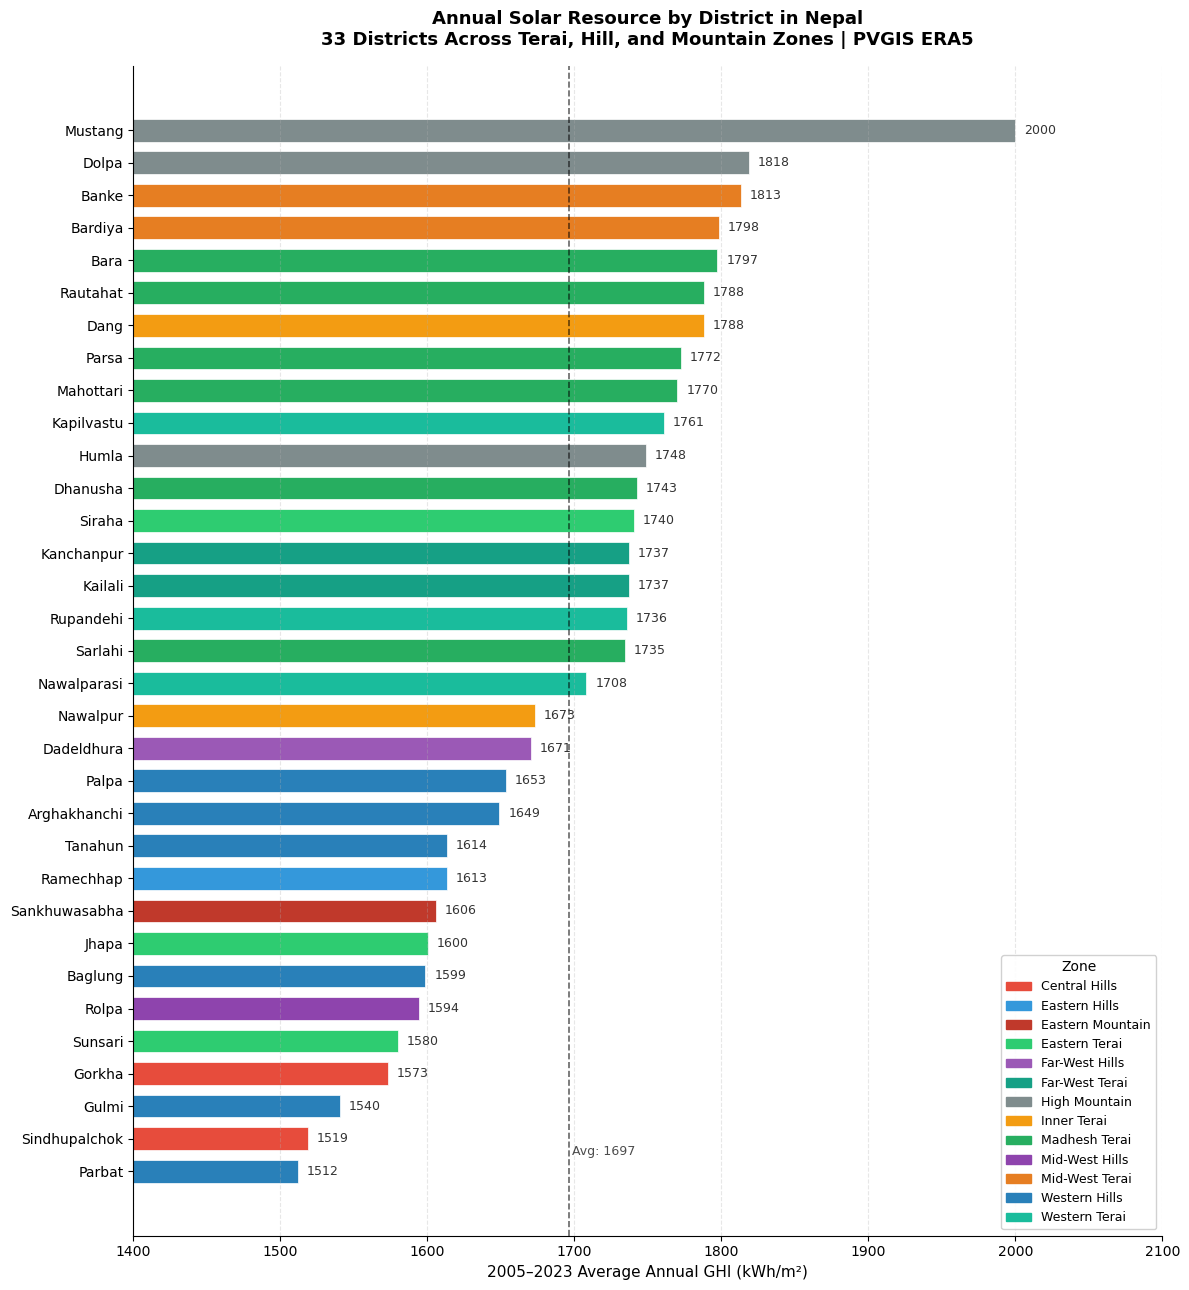

Chart 1 saved.


In [3]:
fig, ax = plt.subplots(figsize=(12, 13))

df_plot = df_annual.sort_values('GHI_annual', ascending=True).copy()
colors = [zone_colors[z] for z in df_plot['zone']]

bars = ax.barh(df_plot['location'], df_plot['GHI_annual'],
               color=colors, edgecolor='white', linewidth=0.5, height=0.7)

for bar, val in zip(bars, df_plot['GHI_annual']):
    ax.text(bar.get_width() + 6, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}', va='center', ha='left', fontsize=9, color='#333333')

avg_ghi = df_annual['GHI_annual'].mean()
ax.axvline(x=avg_ghi, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
ax.text(avg_ghi + 2, 0.5, f'Avg: {avg_ghi:.0f}', fontsize=9, color='black', alpha=0.7)

zone_legend = [mpatches.Patch(color=zone_colors[z], label=z)
               for z in sorted(zone_colors.keys()) if z in df_plot['zone'].values]
ax.legend(handles=zone_legend, title='Zone', loc='lower right',
          fontsize=9, title_fontsize=10, framealpha=0.9)

ax.set_xlabel('2005–2023 Average Annual GHI (kWh/m²)', fontsize=11)
ax.set_title('Annual Solar Resource by District in Nepal\n33 Districts Across Terai, Hill, and Mountain Zones | PVGIS ERA5',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(1400, 2100)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart1_ghi_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

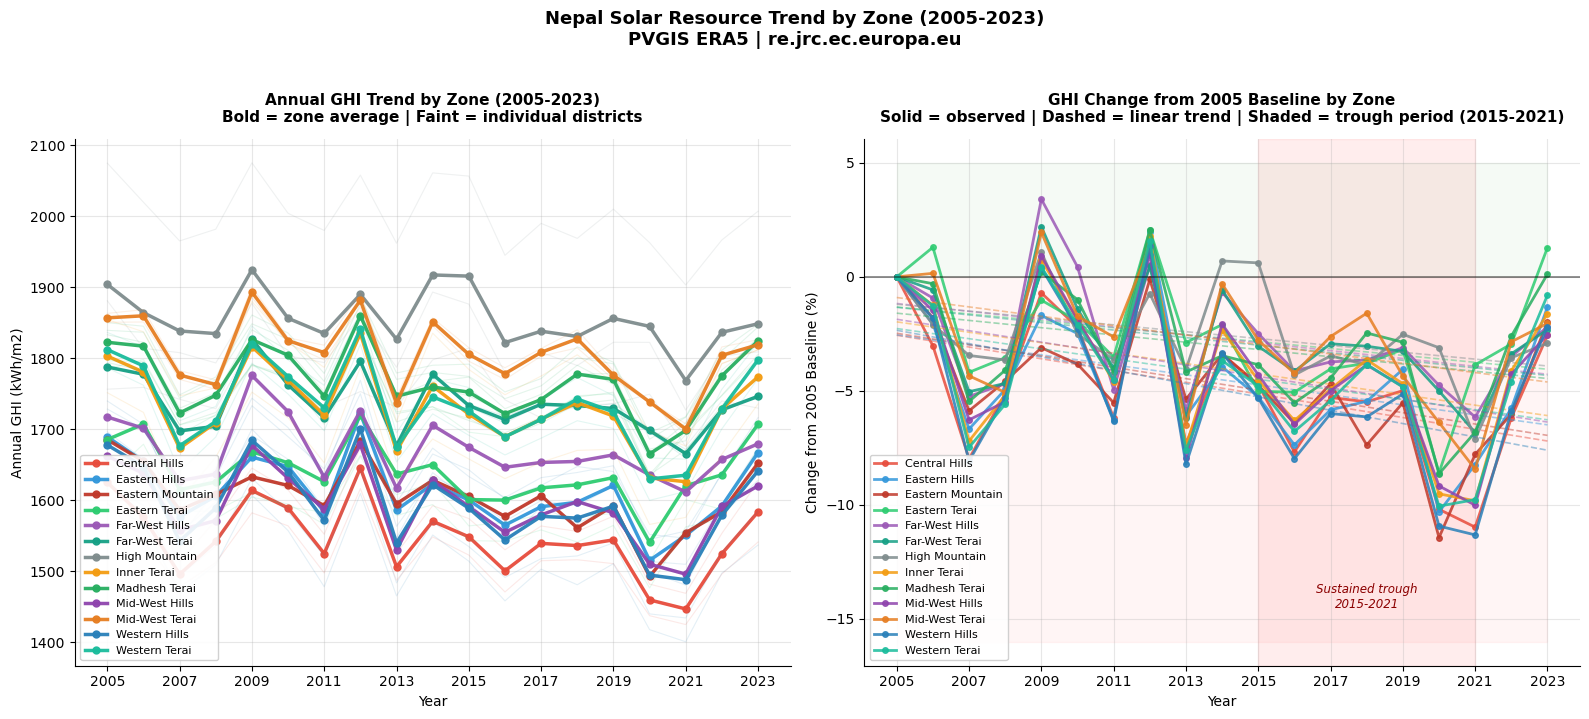

Chart 2 saved.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

df_zone_trend = df_yearly_trend.groupby(['zone', 'year'])['GHI_annual'].mean().reset_index()

# --- LEFT: Absolute GHI trend ---
ax1 = axes[0]

for zone in sorted(df_zone_trend['zone'].unique()):
    color = zone_colors[zone]
    for loc in df_yearly_trend[df_yearly_trend['zone'] == zone]['location'].unique():
        df_loc = df_yearly_trend[df_yearly_trend['location'] == loc]
        ax1.plot(df_loc['year'], df_loc['GHI_annual'],
                 color=color, alpha=0.12, linewidth=0.8)
    df_z = df_zone_trend[df_zone_trend['zone'] == zone]
    ax1.plot(df_z['year'], df_z['GHI_annual'],
             color=color, linewidth=2.5, marker='o', markersize=5,
             label=zone, alpha=0.95)

ax1.set_title('Annual GHI Trend by Zone (2005-2023)\nBold = zone average | Faint = individual districts',
              fontsize=11, fontweight='bold', pad=12)
ax1.set_xlabel('Year', fontsize=10)
ax1.set_ylabel('Annual GHI (kWh/m2)', fontsize=10)
ax1.legend(fontsize=8, loc='lower left', framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(2005, 2024, 2))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- RIGHT: % change from 2005 baseline + linear regression ---
ax2 = axes[1]

for zone in sorted(df_zone_trend['zone'].unique()):
    df_z = df_zone_trend[df_zone_trend['zone'] == zone].copy()
    color = zone_colors[zone]
    baseline = df_z[df_z['year'] == 2005]['GHI_annual'].values[0]
    df_z['pct_change'] = ((df_z['GHI_annual'] - baseline) / baseline) * 100

    # Observed trend line
    ax2.plot(df_z['year'], df_z['pct_change'],
             color=color, linewidth=2, marker='o', markersize=4,
             label=zone, alpha=0.85)

    # Linear regression trend (dashed)
    slope, intercept, r_val, p_val, se = sp_stats.linregress(
        df_z['year'], df_z['pct_change']
    )
    trend_y = slope * df_z['year'] + intercept
    ax2.plot(df_z['year'], trend_y,
             color=color, linewidth=1.2, linestyle='--', alpha=0.45)

ax2.axhline(y=0, color='black', linestyle='-', linewidth=1.2, alpha=0.5)
ax2.fill_between(range(2005, 2024), 0, -16, alpha=0.04, color='red')
ax2.fill_between(range(2005, 2024), 0, 5, alpha=0.04, color='green')

# Shade the sustained trough window
ax2.axvspan(2015, 2021, alpha=0.07, color='red', label='_nolegend_')
ax2.text(2018, -14.5, 'Sustained trough\n2015-2021', fontsize=8.5,
         color='darkred', ha='center', style='italic')

ax2.set_title('GHI Change from 2005 Baseline by Zone\nSolid = observed | Dashed = linear trend | Shaded = trough period (2015-2021)',
              fontsize=11, fontweight='bold', pad=12)
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylabel('Change from 2005 Baseline (%)', fontsize=10)
ax2.legend(fontsize=8, loc='lower left', framealpha=0.9)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(2005, 2024, 2))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Nepal Solar Resource Trend by Zone (2005-2023)\nPVGIS ERA5 | re.jrc.ec.europa.eu',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart2_zone_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

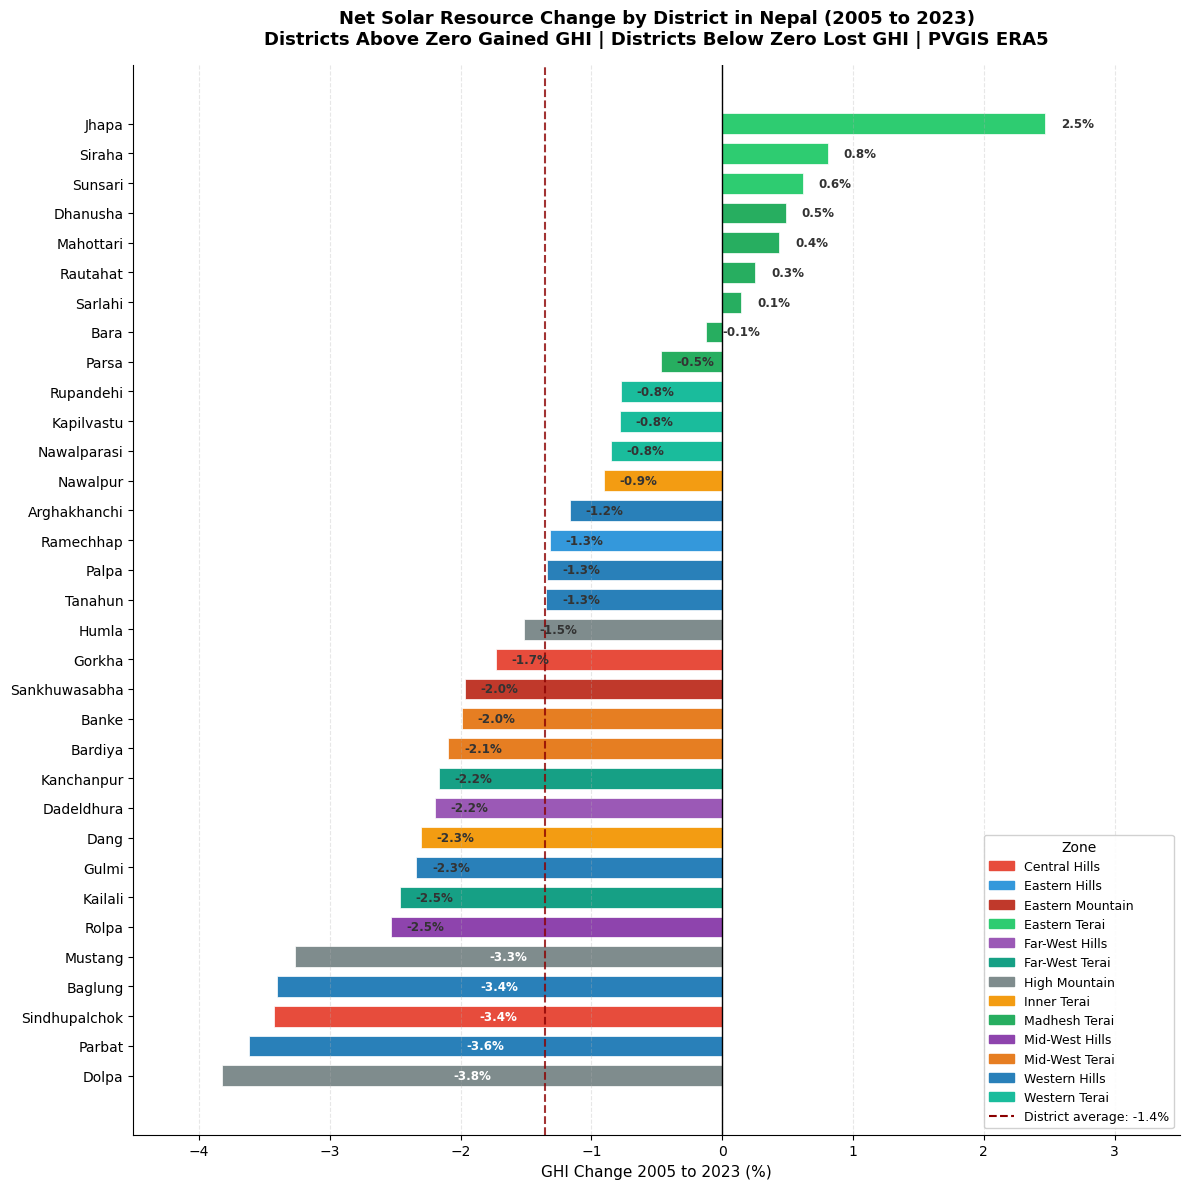

Chart 3 saved.


In [5]:
decline_data = []
for location in df_yearly_trend['location'].unique():
    df_loc = df_yearly_trend[df_yearly_trend['location'] == location]
    zone = df_loc['zone'].values[0]
    val_2005 = df_loc[df_loc['year'] == 2005]['GHI_annual'].values[0]
    val_2023 = df_loc[df_loc['year'] == 2023]['GHI_annual'].values[0]
    change = ((val_2023 - val_2005) / val_2005) * 100
    decline_data.append({'location': location, 'zone': zone, 'change': change})

df_decline = pd.DataFrame(decline_data).sort_values('change', ascending=True)

fig, ax = plt.subplots(figsize=(12, 12))

colors = [zone_colors[z] for z in df_decline['zone']]
bars = ax.barh(df_decline['location'], df_decline['change'],
               color=colors, edgecolor='white', linewidth=0.5, height=0.7)

for bar, (_, row) in zip(bars, df_decline.iterrows()):
    if row['change'] < -3:
        ax.text(row['change'] / 2, bar.get_y() + bar.get_height() / 2,
                f"{row['change']:.1f}%",
                va='center', ha='center', fontsize=8.5,
                color='white', fontweight='bold')
    else:
        ax.text(row['change'] + 0.12, bar.get_y() + bar.get_height() / 2,
                f"{row['change']:.1f}%",
                va='center', ha='left', fontsize=8.5,
                color='#333333', fontweight='bold')

ax.axvline(x=0, color='black', linewidth=1)
avg_change = df_decline['change'].mean()
ax.axvline(x=avg_change, color='darkred', linestyle='--',
           linewidth=1.5, alpha=0.8)

zone_legend = [mpatches.Patch(color=zone_colors[z], label=z)
               for z in sorted(zone_colors.keys()) if z in df_decline['zone'].values]
avg_line = plt.Line2D([0], [0], color='darkred', linestyle='--',
                      linewidth=1.5, label=f'District average: {avg_change:.1f}%')
ax.legend(handles=zone_legend + [avg_line], title='Zone',
          loc='lower right', fontsize=9, title_fontsize=10, framealpha=0.9)

ax.set_xlabel('GHI Change 2005 to 2023 (%)', fontsize=11)
ax.set_title('Net Solar Resource Change by District in Nepal (2005 to 2023)\n'
             'Districts Above Zero Gained GHI | Districts Below Zero Lost GHI | PVGIS ERA5',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(-4.5, 3.5)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart3_ghi_decline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

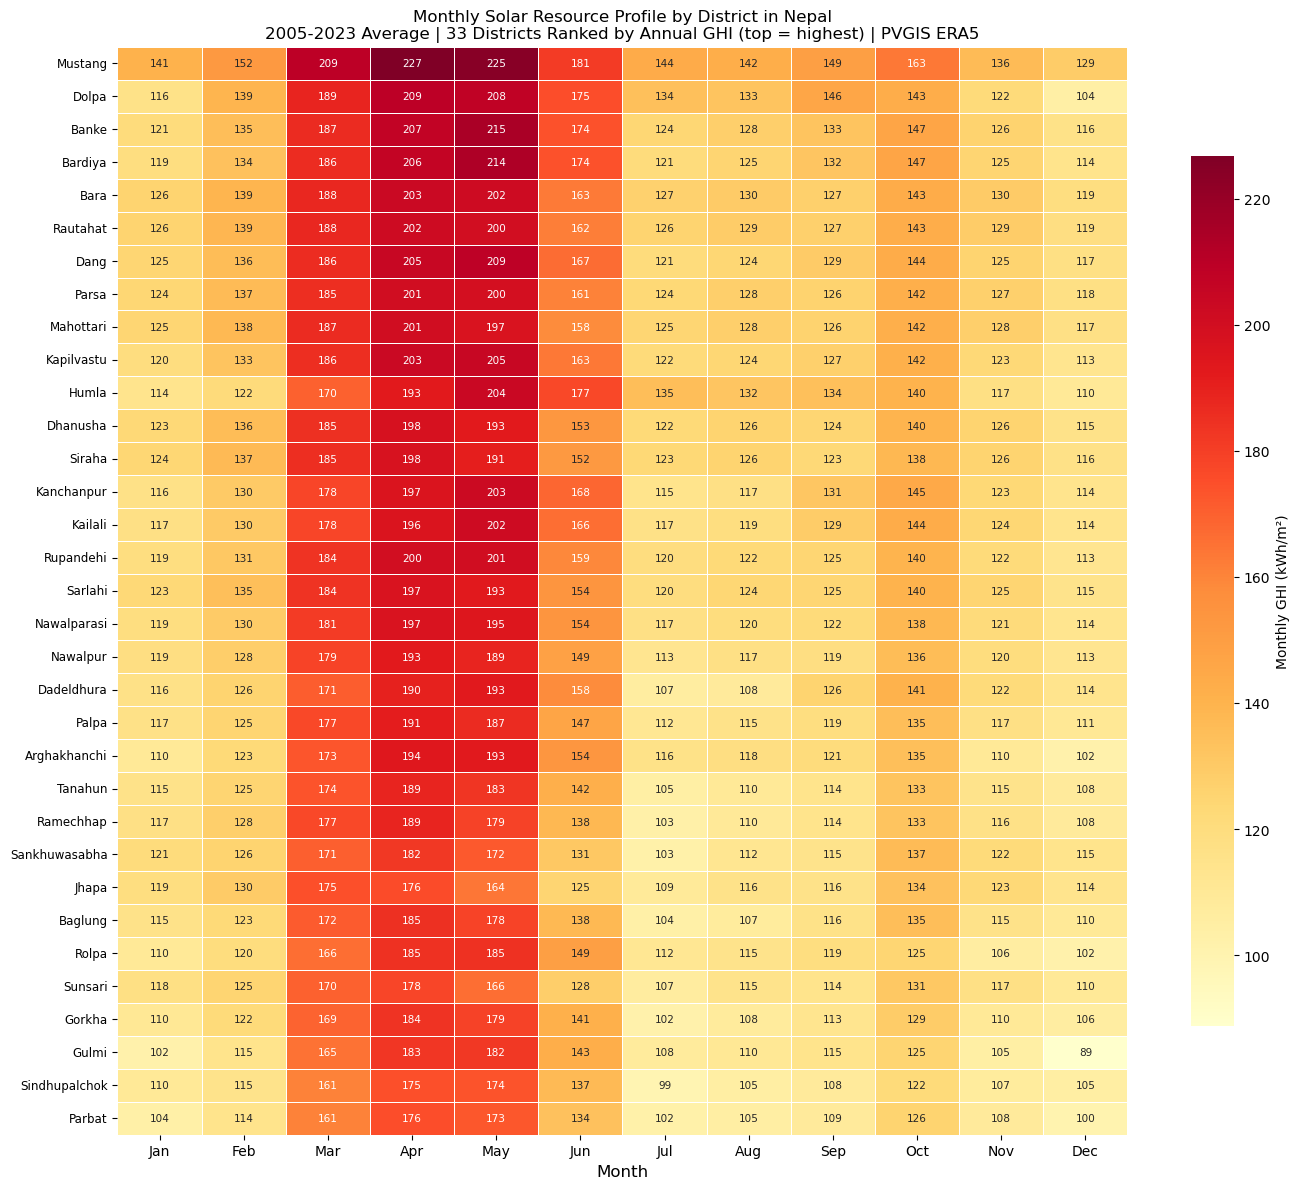

Chart 4 saved.


In [6]:
pivot = df_monthly.pivot_table(index='location', columns='month', values='GHI_monthly')

order = df_annual.sort_values('GHI_annual', ascending=False)['location'].tolist()
pivot = pivot.reindex(order)
pivot.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Monthly GHI (kWh/m²)', 'shrink': 0.8},
            ax=ax, annot_kws={'size': 7.5})

ax.set_title('Monthly Solar Resource Profile by District in Nepal\n'
             '2005-2023 Average | 33 Districts Ranked by Annual GHI (top = highest) | PVGIS ERA5')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8.5)
ax.tick_params(axis='x', labelsize=10, rotation=0)

plt.tight_layout()
plt.savefig('chart4_monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

In [7]:
terai_zones = ["Eastern Terai", "Madhesh Terai", "Western Terai", 
               "Inner Terai", "Mid-West Terai", "Far-West Terai"]

df_terai_monthly = df_monthly[df_monthly['zone'].isin(terai_zones)]

may_vals = df_terai_monthly[df_terai_monthly['month'] == 5]['GHI_monthly']
jul_vals = df_terai_monthly[df_terai_monthly['month'] == 7]['GHI_monthly']

print(f"May range: {may_vals.min():.0f} – {may_vals.max():.0f}")
print(f"July range: {jul_vals.min():.0f} – {jul_vals.max():.0f}")

May range: 164 – 215
July range: 107 – 127


## Key Findings

**Dataset:** PVGIS ERA5 | 2005 to 2023 | 33 districts across Nepal's principal solar resource zones | Phase 1 of 3

**Data source:** European Commission Joint Research Centre, Photovoltaic Geographical Information System (PVGIS), API v5.3
https://re.jrc.ec.europa.eu

**Citation:** Huld T., Muller R., Gambardella A. (2012). A new solar radiation database for estimating PV performance in Europe and Africa. Solar Energy, 86(6), 1803-1815.

---

### Finding 1: Solar Resource Varies Significantly from Year to Year

Nepal's annual GHI is not stable. All 33 districts show clear year-on-year swings throughout the 2005-2023 period. The sharpest pattern is a sustained trough that runs from roughly 2015 to 2021, when most Terai and Hill zones fell 10-13% below their 2005 baseline. GHI recovered toward 2005 levels by 2022-2023.

The net endpoint change from 2005 to 2023 averages -1.4% across all 33 districts. Seven districts show a net gain. Twenty-six show a net decline. But that average understates the risk. The trough lasted approximately six consecutive years. A solar project financed in 2010, using 2005-2010 historical averages to model yield, would have received 10-13% less energy than expected every year from 2015 to 2021. Standard P50 yield estimates treat variability as single-year noise. They do not model multi-year resource troughs.

The inter-annual coefficient of variation (CoV) ranges from 1.9% to 4.0% across districts (see variability table below). Districts with higher CoV carry more yield uncertainty regardless of trend direction.

---

### Finding 2: The 2015-2021 Trough Was Deep and Long-Lasting

The trough visible in Chart 2 is not a single bad year. Most lowland and hill zones stayed below the 2005 baseline continuously from roughly 2014 to 2021. The deepest point was around 2019-2021. The magnitude reached 10-13% below baseline for Terai zones at the worst point.

For a project with a 15-year debt term starting in 2010, this trough falls in years 5 through 11 of debt service. That is when principal balances are still high and debt service coverage ratios are most sensitive to generation shortfalls. A sustained 10-13% generation shortfall over six years is not a tail-risk event. It is what actually happened to the resource between 2015 and 2021.

High Mountain districts (Mustang, Dolpa, Humla) show a different year-to-year pattern than Terai zones, visible in Chart 2. Their trough timing and depth differ from lowland zones. In the 2005-2023 endpoint comparison, these districts show net declines of -1.5% (Humla) to -3.8% (Dolpa), which is larger than several Terai districts that recovered more fully by 2023. The difference in their variability character, rather than a simple lower-decline claim, is what makes them a distinct risk category.

---

### Finding 3: Spatial Pattern in the 2005-2023 Period

The 2005-2023 endpoint comparison shows no consistent east-to-west gradient in Nepal. Eastern Terai districts show net gains: Jhapa +2.5%, Siraha +0.8%, Sunsari +0.6%. Several Western Hill districts show the largest net declines: Parbat -3.6%, Baglung -3.4%, Sindhupalchok -3.4%. The district average is -1.4%.

This pattern does not support a simple aerosol loading gradient from the Indo-Gangetic Plain for the full 2005-2023 period. The aerosol attribution hypothesis will be tested in Phase 3 using MERRA-2 aerosol optical depth data from NASA. Phase 3 will compare spatial GHI patterns within the trough sub-period (2014-2021) against AOD records to determine whether aerosol loading explains the trough shape and geography. That analysis has not been done in this version. The hypothesis is stated here as a direction for Phase 3, not as a confirmed finding.

---

### Finding 4: Monsoon Season Reduces GHI by 35-45% Across Terai and Hill Zones

June to August GHI across Terai and Hill districts is 35-45% lower than the March-May peak. For Terai districts, July GHI averages 107-127 kWh/m2, compared to 164-215 kWh/m2 in May. High Mountain districts north of the orographic barrier show less monsoon suppression because they sit outside the primary monsoon track.

Projects sized on annual P50 assumptions without a monsoon-period downside case carry seasonal risk that compounds the multi-year variability risk described in Finding 1 and Finding 2.

---

### Financing Implication

Solar projects in Nepal are commonly financed using historical GHI averages as the P50 yield basis. The 2005-2023 data shows that a single average figure does not capture multi-year resource trough risk.

The 2015-2021 trough reached 10-13% below the 2005 baseline for lowland zones and lasted roughly six years. This is not a model scenario. It is a documented outcome in a publicly available satellite-reanalysis dataset. Any project currently being financed on 2005-2023 averages should have a P90 scenario that models what happens to debt service coverage if GHI runs 10-12% below the long-term average for five to seven consecutive years.

High Mountain districts present a different risk profile from Terai and Hill zones. Their inter-annual variability differs in timing and depth. Their remoteness, grid connection costs, and terrain-driven construction costs are separate risk dimensions not covered in this analysis.

---

### Limitations

- **Spatial resolution:** The ERA5 grid is approximately 25 km. District centroids are used as query points. Site-specific irradiance will differ from district-level estimates, particularly in complex terrain.
- **Period:** Analysis covers 2005 to 2023 using PVGIS ERA5 database v5.3. This is the full ERA5 period currently available through the PVGIS MRcalc endpoint.
- **Baseline:** 2005 was selected as the baseline year. A sensitivity analysis using a 3-year rolling baseline (2005-2007) is planned for Phase 2 to test whether baseline selection changes the trough magnitude finding.
- **Endpoint comparison:** The endpoint-to-endpoint method (2005 vs 2023) is sensitive to which years are chosen as endpoints. Linear regression trend lines are included in Chart 2 for each zone to show the long-period trend direction independently of the endpoint choice.
- **Variability metric:** Inter-annual variability is quantified as the coefficient of variation (standard deviation divided by mean, expressed as a percentage) across the 19-year period. Higher CoV means the district's annual GHI fluctuates more from year to year.
- **Aerosol attribution:** The aerosol loading hypothesis is stated as a hypothesis for Phase 3. It has not been tested in this version. Confirmation requires cross-referencing with MERRA-2 aerosol optical depth data.
- **District scope:** Phase 1 covers 33 districts selected to represent Nepal's Terai, Hill, and Mountain solar resource zones. Phase 2 will extend to all 77 districts.

*Full code and data available on GitHub.*

In [8]:
import os

# Export processed datasets
df_annual.to_csv('nepal_ghi_annual_by_district.csv', index=False)
df_monthly.to_csv('nepal_ghi_monthly_by_district.csv', index=False)
df_yearly_trend.to_csv('nepal_ghi_yearly_trend.csv', index=False)

# Build and export decline summary (no MW — geographic framing only)
decline_export_data = []
for location in df_yearly_trend['location'].unique():
    df_loc = df_yearly_trend[df_yearly_trend['location'] == location]
    zone = df_loc['zone'].values[0]
    val_2005 = df_loc[df_loc['year'] == 2005]['GHI_annual'].values[0]
    val_2023 = df_loc[df_loc['year'] == 2023]['GHI_annual'].values[0]
    change = ((val_2023 - val_2005) / val_2005) * 100
    decline_export_data.append({
        'district':    location,
        'zone':        zone,
        'lat':         locations[location]['lat'],
        'lon':         locations[location]['lon'],
        'ghi_2005':    round(val_2005, 1),
        'ghi_2023':    round(val_2023, 1),
        'pct_change':  round(change, 2),
    })

df_decline_export = pd.DataFrame(decline_export_data).sort_values('pct_change')
df_decline_export.to_csv('nepal_ghi_decline_summary.csv', index=False)

print("Files exported successfully:")
for f in ['nepal_ghi_annual_by_district.csv',
          'nepal_ghi_monthly_by_district.csv',
          'nepal_ghi_yearly_trend.csv',
          'nepal_ghi_decline_summary.csv']:
    size = os.path.getsize(f)
    print(f"  {f}  ({size:,} bytes)")

Files exported successfully:
  nepal_ghi_annual_by_district.csv  (1,422 bytes)
  nepal_ghi_monthly_by_district.csv  (24,774 bytes)
  nepal_ghi_yearly_trend.csv  (23,506 bytes)
  nepal_ghi_decline_summary.csv  (1,862 bytes)


In [9]:
# --- INTER-ANNUAL VARIABILITY (Coefficient of Variation per district) ---
# CoV = standard deviation / mean x 100
# Higher CoV means GHI swings more from year to year.
# This is the risk metric that annual P50 estimates do not capture.

df_variability = df_yearly_trend.groupby(['location', 'zone'])['GHI_annual'].agg(
    ghi_mean='mean',
    ghi_std='std'
).reset_index()

df_variability['cov_pct'] = (df_variability['ghi_std'] / df_variability['ghi_mean']) * 100

df_variability = df_variability.merge(
    df_decline_export[['district', 'pct_change']].rename(columns={'district': 'location'}),
    on='location'
)
df_variability = df_variability.sort_values('cov_pct', ascending=False).reset_index(drop=True)

df_variability.to_csv('nepal_ghi_variability.csv', index=False)


display(df_variability[['location', 'zone', 'ghi_mean', 'cov_pct', 'pct_change']].round(1).rename(columns={
    'location': 'District',
    'zone': 'Zone',
    'ghi_mean': 'Mean GHI',
    'cov_pct': 'CoV (%)',
    'pct_change': 'Net Change (%)'
}))
print("Inter-Annual GHI Variability by District (2005-2023)")
print("CoV = coefficient of variation | Net change = 2005 vs 2023 endpoint comparison")
print(f"\n{'District':<20} {'Zone':<22} {'Mean GHI':>10} {'CoV (%)':>9} {'Net Change (%)':>15}")
print("-" * 80)
for _, row in df_variability.iterrows():
    print(f"{row['location']:<20} {row['zone']:<22} {row['ghi_mean']:>10.0f} "
          f"{row['cov_pct']:>9.1f} {row['pct_change']:>15.1f}")
print(f"\nDistrict average CoV: {df_variability['cov_pct'].mean():.1f}%")
print(f"Range: {df_variability['cov_pct'].min():.1f}% to {df_variability['cov_pct'].max():.1f}%")

,District,Zone,Mean GHI,CoV (%),Net Change (%)
0,Baglung,Western Hills,1598.7,4.0,-3.4
1,Parbat,Western Hills,1512.1,3.9,-3.6
2,Gulmi,Western Hills,1540.5,3.9,-2.3
3,Palpa,Western Hills,1653.3,3.8,-1.3
4,Tanahun,Western Hills,1613.5,3.7,-1.4
5,Nawalpur,Inner Terai,1672.9,3.6,-0.9
6,Gorkha,Central Hills,1573.0,3.6,-1.7
7,Nawalparasi,Western Terai,1708.2,3.6,-0.8
8,Arghakhanchi,Western Hills,1649.0,3.5,-1.2
9,Rupandehi,Western Terai,1735.5,3.5,-0.8


Inter-Annual GHI Variability by District (2005-2023)
CoV = coefficient of variation | Net change = 2005 vs 2023 endpoint comparison

District             Zone                     Mean GHI   CoV (%)  Net Change (%)
--------------------------------------------------------------------------------
Baglung              Western Hills                1599       4.0            -3.4
Parbat               Western Hills                1512       3.9            -3.6
Gulmi                Western Hills                1540       3.9            -2.3
Palpa                Western Hills                1653       3.8            -1.3
Tanahun              Western Hills                1614       3.7            -1.4
Nawalpur             Inner Terai                  1673       3.6            -0.9
Gorkha               Central Hills                1573       3.6            -1.7
Nawalparasi          Western Terai                1708       3.6            -0.8
Arghakhanchi         Western Hills                1649   